# Monocular Depth Estimation

---

**Tathagata Chowdhury**, ISU ID: <your_ISU_ID>

---

If you have any questions on assignments and for consultations, you can write in telegram [@varkanar](https://t.me/varkanar) or e-mail oaevstafev@itmo.ru.

**General Requirements**
1. You are expected to complete this task on your own.
2. Reasonableness of conclusions.
3. The code must be runnable, the results reproducible. If the data is taken from your google drive, a link to the data must be available.
4. Colab Notebook must contain the results of running the code in cells.
5. The overall structure of this Colab Notebook is maintained. You can introduce additional sections, write additional functions, not drastically change sections. If you remove some text and so on, make sure that all task results remain explicitly labeled.
6. To turn in an assignment, a link to Colab Notebook must be submitted at e-mail oaevstafev@itmo.ru.

In [ ]:
import os, time, pathlib, glob, io
import numpy as np
import keras
import keras.backend as K
import tensorflow as tf
import random
import skimage
try:
    from tensorflow.python.keras.utils import conv_utils
except Exception:
    # conv_utils.normalize_tuple moved/removed in newer TF; provide a fallback
    class _ConvUtils:
        @staticmethod
        def normalize_tuple(value, n, name):
            if isinstance(value, int):
                return (value,) * n
            return tuple(int(v) for v in value)
    conv_utils = _ConvUtils()
from itertools import product, permutations
from matplotlib import pyplot as plt
from contextlib import redirect_stdout
from skimage.transform import resize
from sklearn.utils import shuffle
from keras import applications
from keras.models import Model, load_model
from keras.layers import Conv2D, LeakyReLU, Concatenate, Layer, InputSpec
from tensorflow.keras.utils import Sequence
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from PIL import Image
from zipfile import ZipFile

# Dataset preparation

## Download dataset to Google Drive

To upload the dataset to Google Drive, you can do everything manually:

1. Downloading it from the page https://www.kaggle.com/datasets/soumikrakshit/nyu-depth-v2/data
2. Upload it to Google Drive at https://drive.google.com

To make it automatically run the code from the prepared Colab Notebook

https://colab.research.google.com/drive/1znyMbnthG24p8L_eKtClN-DW1JCujq4w#scrollTo=4IVuj71PnznO

## Copy Dataset to Google Colab Virtual Machine

Mount Google Drive to Colab VM

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


Copy train and validation part of the dataset from Google Drive to Colab VM

**Note** the used path `/content/gdrive/MyDrive/University/MLR/kaggle_datasets` must be replaced with path on your google drive

In [ ]:
!cp '/content/gdrive/MyDrive/University/MLR/kaggle_datasets/nyu-depth-v2.zip' '/content/nyu-depth-v2.zip'

Then unarchive

In [ ]:
!unzip -q '/content/nyu-depth-v2.zip' -d "/content/nyu-depth-v2/"

Copy and unzip the test part of the dataset from Google Drive to Colab VM

**Note** the used path `/content/gdrive/MyDrive/University/MLR/kaggle_datasets` must be replaced with path on your google drive

In [ ]:
!cp '/content/gdrive/MyDrive/University/MLR/kaggle_datasets/nyu_test.zip' '/content/nyu_test.zip'

In [ ]:
!unzip -q '/content/nyu_test.zip' -d "/content/nyu_test/"

## Dataset Utils


Tensors will have the shape (B×H×W×C), where our images are 3-channel arrays, and our depth maps are single-channel arrays.


In [ ]:
import os

def get_nyu_data(data_dir, batch_size, num_samples=None):
    train_csv = os.path.join(data_dir, './nyu_data/data/nyu2_train.csv')
    test_csv = os.path.join(data_dir, './nyu_data/data/nyu2_test.csv')

    with open(train_csv, 'r') as f:
        nyu2_train = [line.strip().split(',') for line in f if line.strip()]

    with open(test_csv, 'r') as f:
        nyu2_test = [line.strip().split(',') for line in f if line.strip()]

    if num_samples:
        nyu2_train = nyu2_train[:num_samples]
        nyu2_test = nyu2_test[:num_samples]

    shape_rgb = (batch_size, 480, 640, 3)
    shape_depth = (batch_size, 240, 320, 1)

    return nyu2_train, nyu2_test, shape_rgb, shape_depth

Function to vizualize data

In [ ]:
def img_is_color(img):

    if len(img.shape) == 3:
        # Check the color channels to see if they're all the same.
        c1, c2, c3 = img[:, : , 0], img[:, :, 1], img[:, :, 2]
        if (c1 == c2).all() and (c2 == c3).all():
            return True

    return False

def show_image_list(list_images, list_titles=None, list_cmaps=None, grid=True, num_cols=2, figsize=(20, 10), title_fontsize=30):
    '''
    Shows a grid of images, where each image is a Numpy array. The images can be either
    RGB or grayscale.

    Parameters:
    ----------
    images: list
        List of the images to be displayed.
    list_titles: list or None
        Optional list of titles to be shown for each image.
    list_cmaps: list or None
        Optional list of cmap values for each image. If None, then cmap will be
        automatically inferred.
    grid: boolean
        If True, show a grid over each image
    num_cols: int
        Number of columns to show.
    figsize: tuple of width, height
        Value to be passed to pyplot.figure()
    title_fontsize: int
        Value to be passed to set_title().
    '''

    assert isinstance(list_images, list)
    assert len(list_images) > 0
    assert isinstance(list_images[0], np.ndarray)

    if list_titles is not None:
        assert isinstance(list_titles, list)
        assert len(list_images) == len(list_titles), '%d imgs != %d titles' % (len(list_images), len(list_titles))

    if list_cmaps is not None:
        assert isinstance(list_cmaps, list)
        assert len(list_images) == len(list_cmaps), '%d imgs != %d cmaps' % (len(list_images), len(list_cmaps))

    num_images  = len(list_images)
    num_cols    = min(num_images, num_cols)
    num_rows    = int(num_images / num_cols) + (1 if num_images % num_cols != 0 else 0)

    # Create a grid of subplots.
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    # Create list of axes for easy iteration.
    if isinstance(axes, np.ndarray):
        list_axes = list(axes.flat)
    else:
        list_axes = [axes]

    for i in range(num_images):

        img    = list_images[i]
        title  = list_titles[i] if list_titles is not None else 'Image %d' % (i)
        cmap   = list_cmaps[i] if list_cmaps is not None else (None if img_is_color(img) else 'gray')

        list_axes[i].imshow(img, cmap=cmap)
        list_axes[i].set_title(title, fontsize=title_fontsize)
        list_axes[i].grid(grid)

    for i in range(num_images, len(list_axes)):
        list_axes[i].set_visible(False)

    fig.tight_layout()
    plt.show()

### Data Augmentation

Data augmentation through geometric and photometric transformations is a standard practice for increasing the diversity of the dataset, which leads to improved training performance.

For this dataset, we will apply the following operations:

*   Color channel modification of the images  
*   Horizontal flipping of the images  
*   Vertical flipping of the images  
*   Adding noise to the images

In [ ]:
class BasicPolicy(object):
    def __init__(self, mirror_ratio=0, flip_ratio=0, color_change_ratio=0, add_noise_peak=0.0):
        # Random order of color channels

        self.indices = list(permutations(range(3), 3)) # Create several different sequences
        self.indices.insert(0, [0, 1, 2])  # R, G, B standard order (no mixing)

        self.add_noise_peak = add_noise_peak   # Percentage of noise added to the image

        # Image flipping
        self.color_change_ratio = color_change_ratio # Probabilty of randomizing the image's color channels
        self.mirror_ratio = mirror_ratio     # Probabilty of horizontal flipping
        self.flip_ratio = flip_ratio         # Probabilty of vertical flipping

    def __call__(self, img, depth):

        imgo = img.copy()
        imgc = img.copy()
        imgm = img.copy()
        imgf = img.copy()
        imgn = img.copy()

        # 1) Color channel modification
        policy_idx = random.randint(0, len(self.indices) - 1)

        #######################################################
        # Apply color change policy
        if random.random() < self.color_change_ratio:
            order = list(self.indices[policy_idx])
            img = img[..., order]
        imgc = img.copy()
        #######################################################

        # 2) Horizontal flipping
        #######################################################
        # Apply horizontal flip policy
        if random.random() < self.mirror_ratio:
            img = img[:, ::-1, :]
            depth = depth[:, ::-1, :]
        imgm = img.copy()
        #######################################################

        # 3) Vertical flipping
        #######################################################
        # Apply vertical flip policy
        if random.random() < self.flip_ratio:
            img = img[::-1, :, :]
            depth = depth[::-1, :, :]
        imgf = img.copy()
        #######################################################

        # 4) Adding noise to the images
        #######################################################
        # Apply Poisson noise with a specified peak
        if self.add_noise_peak > 0:
            peak = self.add_noise_peak
            noisy = np.random.poisson(np.clip(img, 0, 1) * peak) / float(peak)
            img = np.clip(noisy, 0, 1).astype(img.dtype)
        imgn = img.copy()
        #######################################################

        # Uncomment if degug is needed
        # show_image_list(list_images=[imgo, imgc, imgm, imgf, imgn],
        #         list_titles=['original', 'Color change', 'Mirror', 'Flip', 'noise'],
        #         num_cols=3,
        #         figsize=(20, 10),
        #         grid=False,
        #         title_fontsize=20)

        return img, depth

    def __repr__(self):
        return "Basic Policy"

### Data loader

Here we will use the `tensorflow.keras.utils.Sequence` class, which acts as a data loader.

In [ ]:
class NYU_BasicAugmentRGBSequence(Sequence):
    def __init__(self, dataset, batch_size, shape_rgb, shape_depth, is_flip=False, is_addnoise=False,is_apply_policy=True):
        self.dataset = dataset

        self.policy = BasicPolicy(color_change_ratio=0.50, mirror_ratio=0.50, flip_ratio=0.0 if not is_flip else 0.2,add_noise_peak=0 if not is_addnoise else 20)
        self.batch_size = batch_size
        self.shape_rgb = shape_rgb
        self.shape_depth = shape_depth
        self.maxDepth = 1000.0
        self.is_apply_policy = is_apply_policy

        self.dataset = shuffle(self.dataset, random_state=0)

        self.N = len(self.dataset)

    def __len__(self):
        return int(np.ceil(self.N / float(self.batch_size)))

    def __getitem__(self, idx):

        batch_x, batch_y = np.zeros( self.shape_rgb ), np.zeros( self.shape_depth )   # X - rgb-image, Y - depth-image

        for i in range(batch_x.shape[0]):
            index = min((idx * self.batch_size) + i, self.N-1)

            sample = self.dataset[index]

            x = np.clip(np.asarray(Image.open("/content/nyu-depth-v2/nyu_data/"+sample[0])).reshape(480,640,3)/255,0,1)
            y = np.clip(np.asarray(Image.open("/content/nyu-depth-v2/nyu_data/"+sample[1])).reshape(480,640,1)/255*self.maxDepth,0,self.maxDepth)
            y = self.maxDepth / y

            batch_x[i] = resize(x, (480, int(480*4/3)), preserve_range=True, mode='reflect', anti_aliasing=True)
            batch_y[i] = resize(y, (240, int(240*4/3)), preserve_range=True, mode='reflect', anti_aliasing=True)

            if self.is_apply_policy: batch_x[i], batch_y[i] = self.policy(batch_x[i], batch_y[i]) # Применение политики аугументации

        return batch_x, batch_y


In [ ]:
def load_test_data(data_dir):
    print('Loading test data...', end='')

    rgb = np.load(os.path.join(data_dir, './eigen_test_rgb.npy'))
    depth = np.load(os.path.join(data_dir, './eigen_test_depth.npy'))
    crop = np.load(os.path.join(data_dir, './eigen_test_crop.npy'))

    return {'rgb':rgb, 'depth':depth, 'crop':crop}

In [ ]:
batch_size = 4
nyu2_train, nyu2_val, shape_rgb, shape_depth = get_nyu_data('/content/nyu-depth-v2/', batch_size, num_samples=100)
train_generator = NYU_BasicAugmentRGBSequence(nyu2_train, batch_size, shape_rgb, shape_depth, is_apply_policy=True)
val_generator = NYU_BasicAugmentRGBSequence(nyu2_val, batch_size, shape_rgb, shape_depth, is_apply_policy=False)
test_set = load_test_data('/content/nyu_test/')

Loading test data...

### Предварительный просмотр набора данных
Показать часть набора данных, содержащую RGB и соответствующие им карты глубины

In [ ]:
from skimage.transform import resize

def to_multichannel(image):
    """Ensure the image has 3 channels"""
    if image.ndim == 2:
        return np.stack([image] * 3, axis=-1)
    elif image.shape[-1] == 1:
        return np.repeat(image, 3, axis=-1)
    return image

def display_images(outputs=None, inputs=None, gt=None, is_colormap=True, is_rescale=True):
    """
    Displays a batch of images side-by-side (input + output),
    with optional colormap visualization for depth outputs.

    Args:
        outputs: Model outputs (e.g., depth maps), shape (N, H, W, 1)
        inputs: Input images (e.g., RGB), shape (N, H, W, 3)
        gt: Optional generator; if provided, loads one batch from it
        is_colormap: Whether to apply colormap to output (depth) images
        is_rescale: Whether to normalize depth before colormap

    Returns:
        A single image combining the batch in a grid layout
    """
    rainbow = plt.get_cmap('rainbow')

    # Load a batch from generator if provided
    if gt is not None:
        inputs, outputs = gt.__getitem__(2)

    # Resize shape to RGB output size
    shape = (outputs[0].shape[0], outputs[0].shape[1], 3)
    all_images = []

    for i in range(outputs.shape[0]):
        imgs = []

        # Process input image
        if isinstance(inputs, (list, tuple, np.ndarray)):
            x = inputs[i]
            x = resize(x, shape, preserve_range=True, mode='reflect', anti_aliasing=True)
            imgs.append(to_multichannel(x))

        # Process output (depth map)
        if is_colormap:
            rescaled = outputs[i][:, :, 0]
            if is_rescale:
                rescaled = rescaled - np.min(rescaled)
                max_val = np.max(rescaled)
                if max_val > 0:
                    rescaled /= max_val
            imgs.append(rainbow(rescaled)[..., :3])
        else:
            imgs.append(to_multichannel(outputs[i]))

        # Stack input and output horizontally
        img_set = np.hstack(imgs)
        all_images.append(img_set)

    # Convert to array
    all_images = np.array(all_images)

    # Determine grid size
    rows = int(np.ceil(np.sqrt(len(all_images))))
    cols = int(np.ceil(len(all_images) / rows))

    # Pad with empty images if needed
    missing = rows * cols - len(all_images)
    if missing > 0:
        filler = np.zeros_like(all_images[0])
        all_images = np.concatenate([all_images, [filler] * missing], axis=0)

    # Build the grid row by row
    grid_rows = []
    for i in range(rows):
        row = np.hstack(all_images[i * cols:(i + 1) * cols])
        grid_rows.append(row)
    viz = np.vstack(grid_rows)

    return viz

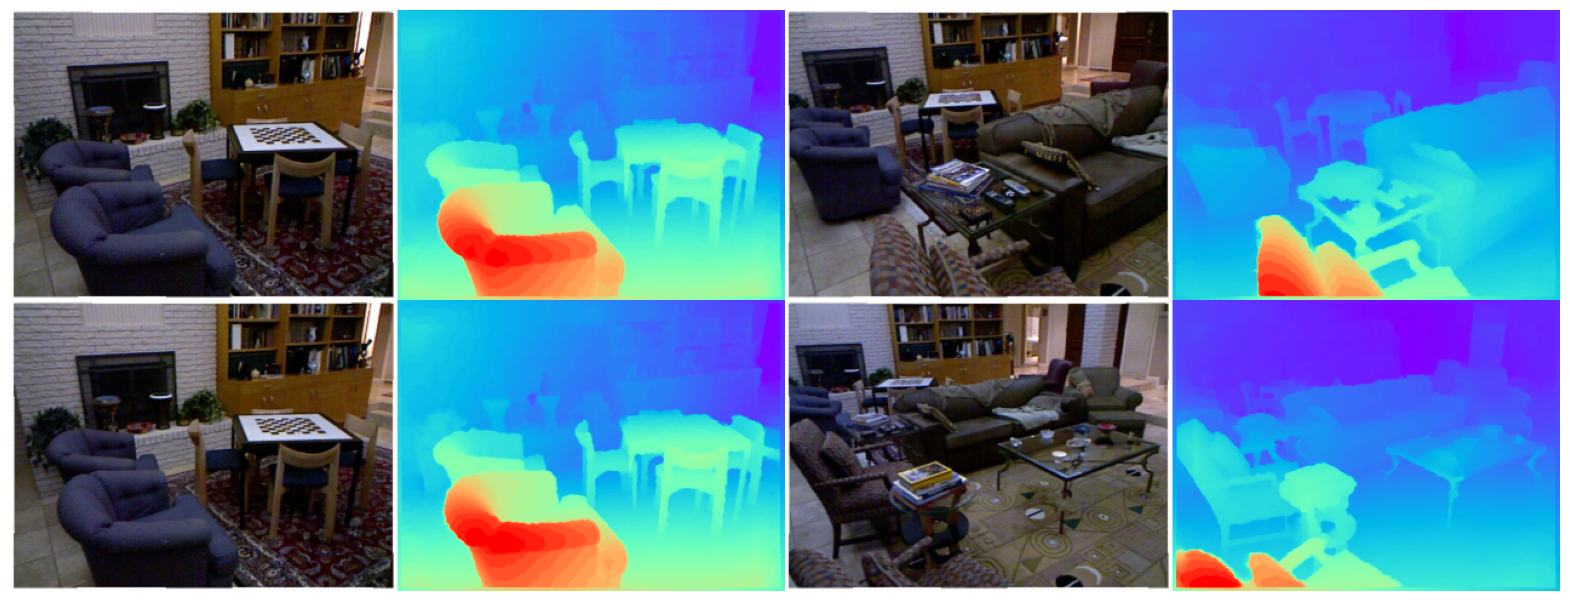

In [ ]:
viz = display_images(gt=train_generator)
plt.figure(figsize=(20, 8))
plt.imshow(viz)
plt.axis('off')
plt.show()

Display elements of val and test parts of dataset

In [ ]:
# Preview validation part of the dataset (RGB + depth)
viz = display_images(gt=val_generator)
plt.figure(figsize=(20, 8))
plt.imshow(viz)
plt.axis('off')
plt.title('Validation samples: RGB + depth')
plt.show()

In [ ]:
# Preview a few samples from the test set (already-loaded numpy arrays)
n_prev = 6
plt.figure(figsize=(20, 7))
rainbow = plt.get_cmap('rainbow')
for i in range(n_prev):
    plt.subplot(2, n_prev, i + 1)
    plt.imshow(test_set['rgb'][i].astype('uint8'))
    plt.axis('off'); plt.title('rgb')

    d = test_set['depth'][i]
    d = (d - d.min()) / (d.max() - d.min() + 1e-8)
    plt.subplot(2, n_prev, i + n_prev + 1)
    plt.imshow(rainbow(d)[..., :3])
    plt.axis('off'); plt.title('depth')
plt.suptitle('Test samples')
plt.show()

### Build the Model

This model is an encoder-decoder network for depth estimation.  
In the encoder, the input RGB image is encoded into a feature vector using a [DenseNet-169 architecture](https://ieeexplore.ieee.org/document/8099726) pretrained on [ImageNet](https://image-net.org/about.php).

The decoder, built from the following layers, performs the following operations:

1. A 1×1 convolution layer on the encoder output, with the number of features equal to that of the final encoder layer.  
2. Four consecutive **upsampling blocks** with corresponding skip connections.  
3. A 3×3 convolution layer at the output of the decoder, producing a single-channel depth map.

Each upsampling block includes the following layers:

1. 2×2 bilinear upsampling  
2. Concatenation with corresponding encoder features  
3. A 3×3 convolution layer with the number of features equal to half of the previous input's feature channels  
4. Another 3×3 convolution layer with the number of features equal to half of the previous input's feature channels  

The architecture of the network is illustrated in the table below:

| **Layer**     | **Output**         | **Function**                           |
|---------------|--------------------|----------------------------------------|
| INPUT         | 480 × 640 × 3      |                                        |
| CONV1         | 240 × 320 × 64     | DenseNet CONV1                         |
| POOL1         | 120 × 160 × 64     | DenseNet POOL1                         |
| POOL2         | 60 × 80 × 128      | DenseNet POOL2                         |
| POOL3         | 30 × 40 × 256      | DenseNet POOL3                         |
| …             | …                  | …                                      |
| CONV2         | 15 × 20 × 832      | Convolution 1 × 1 of DenseNet BLOCK4   |
| UP1           | 30 × 40 × 832      | Upsample 2 × 2                         |
| CONCAT1       | 30 × 40 × 1088     | Concatenate POOL3                      |
| UP1-CONVA     | 30 × 40 × 416      | Convolution 3 × 3                      |
| UP1-CONVB     | 30 × 40 × 416      | Convolution 3 × 3                      |
| UP2           | 60 × 80 × 416      | Upsample 2 × 2                         |
| CONCAT2       | 60 × 80 × 544      | Concatenate POOL2                      |
| UP2-CONVA     | 60 × 80 × 208      | Convolution 3 × 3                      |
| UP2-CONVB     | 60 × 80 × 208      | Convolution 3 × 3                      |
| UP3           | 120 × 160 × 208    | Upsample 2 × 2                         |
| CONCAT3       | 120 × 160 × 272    | Concatenate POOL1                      |
| UP3-CONVA     | 120 × 160 × 104    | Convolution 3 × 3                      |
| UP3-CONVB     | 120 × 160 × 104    | Convolution 3 × 3                      |
| UP4           | 240 × 320 × 104    | Upsample 2 × 2                         |
| CONCAT3       | 240 × 320 × 168    | Concatenate CONV1                      |
| UP2-CONVA     | 240 × 320 × 52     | Convolution 3 × 3                      |
| UP2-CONVB     | 240 × 320 × 52     | Convolution 3 × 3                      |
| CONV3         | 240 × 320 × 1      | Convolution 3 × 3                      |


---

#### Names of the key encoder layers to be used:

- `'pool3_pool'`  
- `'pool2_pool'`  
- `'pool'`  
- `'conv1/relu'`


In [ ]:
class BilinearUpSampling2D(Layer):
    def __init__(self, size=(2, 2), data_format=None, **kwargs):
        super(BilinearUpSampling2D, self).__init__(**kwargs)
        if data_format is None:
            data_format = K.image_data_format()
        self.data_format = data_format.lower()
        self.size = conv_utils.normalize_tuple(size, 2, 'size')
        self.input_spec = InputSpec(ndim=4)

    def compute_output_shape(self, input_shape):
        if self.data_format == 'channels_first':
            height = self.size[0] * input_shape[2] if input_shape[2] is not None else None
            width = self.size[1] * input_shape[3] if input_shape[3] is not None else None
            return (input_shape[0],input_shape[1],height,width)
        elif self.data_format == 'channels_last':
            height = self.size[0] * input_shape[1] if input_shape[1] is not None else None
            width = self.size[1] * input_shape[2] if input_shape[2] is not None else None
            return (input_shape[0],height,width,input_shape[3])

    def call(self, inputs):
        input_shape = K.shape(inputs)
        if self.data_format == 'channels_first':
            height = self.size[0] * input_shape[2] if input_shape[2] is not None else None
            width = self.size[1] * input_shape[3] if input_shape[3] is not None else None
        elif self.data_format == 'channels_last':
            height = self.size[0] * input_shape[1] if input_shape[1] is not None else None
            width = self.size[1] * input_shape[2] if input_shape[2] is not None else None

        return tf.image.resize(inputs, [height, width], method=tf.image.ResizeMethod.BILINEAR)

    def get_config(self):
        config = {'size': self.size, 'data_format': self.data_format}
        base_config = super(BilinearUpSampling2D, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


def create_model():
        print('Loading base model (DenseNet)..')
        # Encoder layers

        base_model = applications.densenet.DenseNet169(input_shape=(None, None, 3), include_top=False)

        print('Base model loaded.')

        # Starting point for the decoder
        base_model_output_shape = base_model.layers[-1].output.shape

        # Train or not traing base_model layers
        for layer in base_model.layers: layer.trainable = True

        # Initial number of decoder filters
        decode_filters = int(int(base_model_output_shape[-1]) / 2)

        # Function for upsampling block
        def upproject(tensor, filters, name, concat_with):
            up_i = BilinearUpSampling2D((2, 2), name=name + '_upsampling2d')(tensor)
            up_i = Concatenate(name=name + '_concat')([up_i, base_model.get_layer(concat_with).output])  # Skip connection
            up_i = Conv2D(filters=filters, kernel_size=3, strides=1, padding='same', name=name + '_convA')(up_i)
            up_i = LeakyReLU(alpha=0.2)(up_i)
            up_i = Conv2D(filters=filters, kernel_size=3, strides=1, padding='same', name=name + '_convB')(up_i)
            up_i = LeakyReLU(alpha=0.2)(up_i)
            return up_i

        #######################################################
        # Decoder implemented according to the architecture table.
        # CONV2: 1x1 conv on encoder output, channels = decode_filters (832).
        decoder0 = Conv2D(filters=decode_filters, kernel_size=1, padding='same',
                          name='conv2', input_shape=base_model_output_shape)(base_model.output)

        # Four upsampling blocks with skip connections to the named encoder layers.
        # Filters halve each block: 832/2=416, 208, 104, 52.
        decoder1 = upproject(decoder0, int(decode_filters / 2),  'up1', concat_with='pool3_pool')
        decoder2 = upproject(decoder1, int(decode_filters / 4),  'up2', concat_with='pool2_pool')
        decoder3 = upproject(decoder2, int(decode_filters / 8),  'up3', concat_with='pool1')
        decoder4 = upproject(decoder3, int(decode_filters / 16), 'up4', concat_with='conv1/relu')

        # CONV3: final 3x3 conv -> single-channel depth map.
        conv3 = Conv2D(filters=1, kernel_size=3, strides=1, padding='same', name='conv3')(decoder4)
        #######################################################

        # Create model
        model = Model(inputs=base_model.input, outputs=conv3)

        print('Model created.')

        return model

# Run model creation
model = create_model()

## Set hyperparameters

In [ ]:
learning_rate = 1e-4
batch_size = 4
epochs = 20

runID = str(int(time.time())) + '-n' + str(len(train_generator)) + '-e' + str(epochs) + '-bs' + str(batch_size) + '-lr' + str(learning_rate)
# Save run artifacts on Google Drive (change to your own path if needed)
outputPath = '/content/gdrive/MyDrive/University/MLR/models/'
runPath = outputPath + runID
pathlib.Path(runPath).mkdir(parents=True, exist_ok=True)
print('Output: ' + runPath)

# Loss Function

The overall loss function can be defined as follows:  
$$L(y, \hat{y})=\lambda L_{\text{depth}}(y, \hat{y}) + L_{\text{grad}}(y, \hat{y}) + L_{SSIM}(y, \hat{y})$$

This loss function consists of three components:

* $L_{\text{depth}}$ is the $L_1$ loss computed on the depth values:

$$
L_{\text{depth}}(y, \hat{y}) = \frac{1}{n} \sum_{p}^{n} \left| y_p - \hat{y}_p \right|
$$

* $L_{\text{grad}}$ is the $L_1$ loss computed on the gradients $g$ of the depth map:

$$
L_{\text{grad}}(y, \hat{y}) = \frac{1}{n} \sum_{p}^{n} \left| \boldsymbol{g}_{\mathbf{x}}(y_p, \hat{y}_p) \right| + \left| \boldsymbol{g}_{\mathbf{y}}(y_p, \hat{y}_p) \right|
$$

* $L_{SSIM}$ uses the Structural Similarity Index (SSIM), which is widely used in image reconstruction tasks:

$$
L_{SSIM}(y, \hat{y}) = \frac{1 - SSIM(y, \hat{y})}{2}
$$

In [ ]:
def depth_loss_function(y_true, y_pred, theta=0.1, maxDepthVal=1000.0 / 10.0):

    #######################################################
    # Point-wise L1 depth loss
    l_depth = K.mean(K.abs(y_pred - y_true), axis=-1)

    # Edges (image gradients) L1 loss
    dy_true, dx_true = tf.image.image_gradients(y_true)
    dy_pred, dx_pred = tf.image.image_gradients(y_pred)
    l_edges = K.mean(K.abs(dy_pred - dy_true) + K.abs(dx_pred - dx_true), axis=-1)

    # Structural similarity (SSIM) loss
    l_ssim = K.clip((1 - tf.image.ssim(y_true, y_pred, max_val=maxDepthVal)) * 0.5, 0, 1)
    #######################################################

    # Weights
    w1 = 1.0
    w2 = 1.0
    w3 = theta

    return (w1 * l_ssim) + (w2 * K.mean(l_edges)) + (w3 * K.mean(l_depth))

# Accuracy Metrics

There are several metrics commonly used to evaluate the performance of depth estimation:

* **Mean Relative Error**  

$$
\frac{1}{n} \sum_{p}^{n} \frac{\left|y_{p} - \hat{y}_{p}\right|}{y_{p}}
$$

* **Root Mean Squared Error (RMSE)**  

$$
\sqrt{\frac{1}{n} \sum_{p}^{n} \left(y_{p} - \hat{y}_{p}\right)^2}
$$

* **Mean Log$_{10}$ Error**  

$$
\frac{1}{n} \sum_{p}^{n} \left| \log_{10}(y_p) - \log_{10}(\hat{y}_p) \right|
$$

* **Threshold Accuracy** (%) — $\delta_i$ from $y_p$ such that:

$$
\max \left( \frac{y_p}{\hat{y}_p}, \frac{\hat{y}_p}{y_p} \right) = \delta < \text{thr}, \quad \text{for} \ \text{thr} = 1.25,\ 1.25^2,\ 1.25^3
$$


In [ ]:
def compute_errors(gt, pred):
    thresh = np.maximum((gt / pred), (pred / gt))

    a1 = (thresh < 1.25).mean()
    a2 = (thresh < 1.25 ** 2).mean()
    a3 = (thresh < 1.25 ** 3).mean()

    abs_rel = np.mean(np.abs(gt - pred) / gt)

    rmse = np.sqrt(((gt - pred) ** 2).mean())

    log_10 = np.mean(np.abs(np.log10(gt) - np.log10(pred)))

    return a1, a2, a3, abs_rel, rmse, log_10

# Model training





Generalized predict function

In [ ]:
def predict(model, images, minDepth=10, maxDepth=1000, batch_size=2):
    # Support for multiple RGB images, a single RGB image, or grayscale images
    if len(images.shape) < 3: images = np.stack((images, images, images), axis=2)
    if len(images.shape) < 4: images = images.reshape((1, images.shape[0], images.shape[1], images.shape[2]))

    # Make predictions
    predictions = model.predict(images, batch_size=batch_size)   # Keras models have a built-in model.predict() function

    # Output in the expected range
    return np.clip(maxDepth / predictions, minDepth, maxDepth) / maxDepth

Generalized evaluation function

In [ ]:
def scale_up(scale, images):
    scaled = []
    for i in range(len(images)):
        img = images[i]
        output_shape = (scale * img.shape[0], scale * img.shape[1])
        scaled.append(resize(img, output_shape, order=1, preserve_range=True, mode='reflect', anti_aliasing=True))
    return np.stack(scaled)

def evaluate(model, rgb, depth, crop, batch_size):
    N = len(rgb)

    bs = batch_size

    predictions = []
    testSetDepths = []

    for i in range(N // bs):
        x = rgb[(i) * bs:(i + 1) * bs, :, :, :]

        # Calc predictions
        true_y = depth[(i) * bs:(i + 1) * bs, :, :]
        pred_y = scale_up(2, predict(model, x / 255, minDepth=10, maxDepth=1000, batch_size=bs)[:, :, :, 0]) * 10.0

        # Crop images
        true_y = true_y[:, crop[0]:crop[1] + 1, crop[2]:crop[3] + 1]
        pred_y = pred_y[:, crop[0]:crop[1] + 1, crop[2]:crop[3] + 1]

        for j in range(len(true_y)):
            predictions.append(pred_y[j])
            testSetDepths.append(true_y[j])

    predictions = np.stack(predictions, axis=0)
    testSetDepths = np.stack(testSetDepths, axis=0)

    e = compute_errors(predictions, testSetDepths)

    print("{:>10}, {:>10}, {:>10}, {:>10}, {:>10}, {:>10}".format('a1', 'a2', 'a3', 'rel', 'rms', 'log_10'))
    print("{:10.4f}, {:10.4f}, {:10.4f}, {:10.4f}, {:10.4f}, {:10.4f}".format(e[0], e[1], e[2], e[3], e[4], e[5]))
    return e

Callback for each training epoch

In [ ]:
def get_nyu_callbacks(model, train_generator, val_generator, test_set, runPath,do_eval):
    callbacks = []

    # Callback for TensorBoard
    class LRTensorBoard(keras.callbacks.TensorBoard):
        def __init__(self, log_dir):
            super().__init__(log_dir=log_dir)
            self.writer = tf.summary.create_file_writer(log_dir)

        def on_epoch_end(self, epoch, logs=None):
              # Calc metrics after each epoch
              if do_eval:
                e = evaluate(model,test_set['rgb'], test_set['depth'], test_set['crop'], batch_size)
                #######################################################
                # Log the test metrics to TensorBoard
                with self.writer.as_default():
                    tf.summary.scalar('a1', e[0], step=epoch)
                    tf.summary.scalar('a2', e[1], step=epoch)
                    tf.summary.scalar('a3', e[2], step=epoch)
                    tf.summary.scalar('rel', e[3], step=epoch)
                    tf.summary.scalar('rmse', e[4], step=epoch)
                    tf.summary.scalar('log10', e[5], step=epoch)
                    self.writer.flush()
                #######################################################

              super().on_epoch_end(epoch, logs)

    callbacks.append(LRTensorBoard(log_dir=runPath))

    # Calback for scheduler
    lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=5, min_lr=0.00009,min_delta=1e-2)
    callbacks.append(lr_schedule)  # reduce lr

    return callbacks

Final Preparations and Training Start

In [ ]:
optimizer = Adam(learning_rate=learning_rate, amsgrad=True)
model.compile(loss=depth_loss_function, optimizer=optimizer)
callbacks = get_nyu_callbacks(model, train_generator, val_generator, test_set, runPath, do_eval=False)
# model.fit accepts a keras Sequence directly (fit_generator was removed in TF 2.x)
history = model.fit(train_generator, callbacks=callbacks, validation_data=val_generator,
                    epochs=epochs, shuffle=True)

### Logging to TensorBoard

Display the training log and evaluation metrics in TensorBoard

In [ ]:
# Load TensorBoard extension
%load_ext tensorboard
import datetime
%tensorboard --logdir {runPath}

# Results

In [ ]:
def load_images(image_files):
    loaded_images = []
    for file in image_files:
        # load RGB image, resize to the network input size, scale to [0,1]
        x = np.clip(np.asarray(Image.open(file).convert('RGB').resize((640, 480)),
                               dtype=float) / 255, 0, 1)
        loaded_images.append(x)
    return np.stack(loaded_images, axis=0)
inputs = load_images(glob.glob('/content/gdrive/MyDrive/University/MLR/examples/*.png'))

outputs = predict(model, inputs)

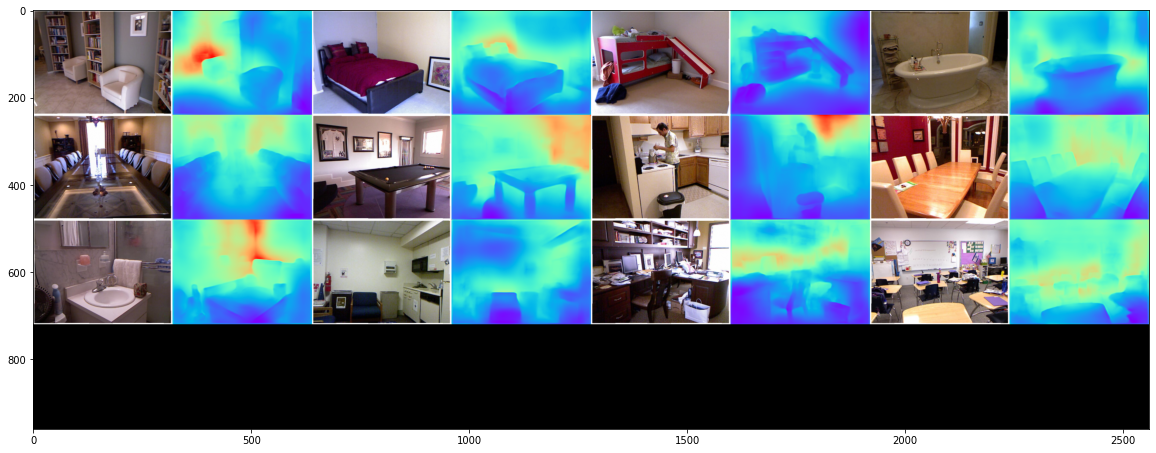

In [ ]:
viz = display_images(outputs=outputs.copy(), inputs=inputs.copy())
plt.figure(figsize=(20,20))
plt.imshow(viz)
plt.savefig('test.png')
plt.show()